# 1. LECTURA DE DATOS

In [2]:
import pandas as pd
df = pd.read_json("Streaming_History_Audio_2012-2025.json",  encoding='utf-8')
# Escribir DataFrame a JSON
df.to_json('archivo_salida.json', orient='records', force_ascii=False, indent=4)
df

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode
0,2012-05-21T07:41:54Z,Windows 7 (Unknown Ed) SP1 [x86 0],20290,ES,88.23.231.199,Froggie Went A Courtin',Bob Dylan,Good As I Been To You,spotify:track:4Qtx7E5HwEamsovSnGAq6H,None,...,NaN,NaN,NaN,uriopen,uriopen,False,True,False,NaN,False
1,2012-05-21T07:41:56Z,Windows 7 (Unknown Ed) SP1 [x86 0],2182,ES,88.23.231.199,Don’t Stop The Party,Black Eyed Peas,The Beginning,spotify:track:6WzHwmlEXBtygh04Q3Q91I,None,...,NaN,NaN,NaN,uriopen,uriopen,False,True,False,NaN,False
2,2012-05-21T07:41:57Z,Windows 7 (Unknown Ed) SP1 [x86 0],2461,ES,88.23.231.199,Give Me Everything (feat. Nayer),Pitbull,Planet Pit (Deluxe Version),spotify:track:4QNpBfC0zvjKqPJcyqBy9W,None,...,NaN,NaN,NaN,uriopen,uriopen,False,True,False,NaN,False
3,2012-05-21T07:43:59Z,Windows 7 (Unknown Ed) SP1 [x86 0],2600,ES,88.23.231.199,I'm Not Alone - Deadmau5 Mix,Calvin Harris,I'm Not Alone (Remixes),spotify:track:1xFPRq7rzAxdLVysdIQWXH,None,...,NaN,NaN,NaN,uriopen,popup,False,True,False,NaN,False
4,2012-05-21T07:47:41Z,Windows 7 (Unknown Ed) SP1 [x86 0],223485,ES,88.23.231.199,Speed of Sound,Coldplay,X&Y,spotify:track:1IfeOJhEPlzmZFnJewpeB6,None,...,NaN,NaN,NaN,popup,popup,False,True,False,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13943,2025-02-04T17:35:21Z,ios,219960,ES,31.4.151.3,CONTIGO VOY A MUERTE,KAROL G,KG0516,spotify:track:615XWyY2RPfk3iuYcU6qvi,None,...,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1.738690e+09,False
13944,2025-02-04T17:37:47Z,ios,64902,ES,31.4.151.3,Eazt,Jay Wheeler,De Mi Para Ti,spotify:track:4et8cFiIp4NPpWfULoukzc,None,...,NaN,NaN,NaN,trackdone,fwdbtn,True,True,False,1.738691e+09,False
13945,2025-02-04T17:37:51Z,ios,3854,ES,31.4.151.3,Lugar Seguro,Jay Wheeler,Emociones,spotify:track:2VF8TTWczzupwrhtsQfx48,None,...,NaN,NaN,NaN,fwdbtn,fwdbtn,True,True,False,1.738691e+09,False
13946,2025-02-04T17:41:27Z,ios,217213,ES,31.4.151.3,200 COPAS,KAROL G,KG0516,spotify:track:0aZnyTWJNgdzYoOiaW8HKG,None,...,NaN,NaN,NaN,fwdbtn,trackdone,True,False,False,1.738691e+09,False


In [3]:
df.isnull().sum()

ts                                       0
platform                                 0
ms_played                                0
conn_country                             0
ip_addr                                  0
master_metadata_track_name              18
master_metadata_album_artist_name       18
master_metadata_album_album_name        18
spotify_track_uri                       18
episode_name                         13930
episode_show_name                    13930
spotify_episode_uri                  13930
audiobook_title                      13948
audiobook_uri                        13948
audiobook_chapter_uri                13948
audiobook_chapter_title              13948
reason_start                             0
reason_end                               0
shuffle                                  0
skipped                                  0
offline                                  0
offline_timestamp                    12269
incognito_mode                           0
dtype: int6

# 2. TRANSFORMACIÓN DEL DF

## 2.1. Eliminación de columnas con valores nulos

In [6]:
print(df.columns)

Index(['ts', 'platform', 'ms_played', 'conn_country', 'ip_addr',
       'master_metadata_track_name', 'master_metadata_album_artist_name',
       'master_metadata_album_album_name', 'spotify_track_uri', 'episode_name',
       'episode_show_name', 'spotify_episode_uri', 'audiobook_title',
       'audiobook_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title',
       'reason_start', 'reason_end', 'shuffle', 'skipped', 'offline',
       'offline_timestamp', 'incognito_mode'],
      dtype='object')


In [7]:
df = df.drop(['episode_name','episode_show_name', 'spotify_episode_uri', 'audiobook_title',
       'audiobook_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title', 'offline_timestamp', ], axis = 1)

print(df.columns)


Index(['ts', 'platform', 'ms_played', 'conn_country', 'ip_addr',
       'master_metadata_track_name', 'master_metadata_album_artist_name',
       'master_metadata_album_album_name', 'spotify_track_uri', 'reason_start',
       'reason_end', 'shuffle', 'skipped', 'offline', 'incognito_mode'],
      dtype='object')


* Voy a eliminar también las filas con valores nulos en las columnas de 'master' porque tampoco me va a servir de nada tener los datos de la música que he escuchado sin sus títulos, artistas o albumes. No las quiero utilizar porque esta es la infomación principal.

In [9]:
df.isnull().sum()

ts                                    0
platform                              0
ms_played                             0
conn_country                          0
ip_addr                               0
master_metadata_track_name           18
master_metadata_album_artist_name    18
master_metadata_album_album_name     18
spotify_track_uri                    18
reason_start                          0
reason_end                            0
shuffle                               0
skipped                               0
offline                               0
incognito_mode                        0
dtype: int64

In [10]:
df.dropna(inplace = True)
df.isnull().sum()

ts                                   0
platform                             0
ms_played                            0
conn_country                         0
ip_addr                              0
master_metadata_track_name           0
master_metadata_album_artist_name    0
master_metadata_album_album_name     0
spotify_track_uri                    0
reason_start                         0
reason_end                           0
shuffle                              0
skipped                              0
offline                              0
incognito_mode                       0
dtype: int64

## 2.2. Eliminación de otras columnas innecesarias y otras transformaciones

* Ahora que me he quedado con un df sin nulos voy a ver si hay alguna columna más que no me aporte información relevante para eliminarla antes de hacer otras transforaciones

In [13]:
# Muestro las columnas de nuevo para ver la información que contienen y descartar las que no me interesan
df.head()

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode
0,2012-05-21T07:41:54Z,Windows 7 (Unknown Ed) SP1 [x86 0],20290,ES,88.23.231.199,Froggie Went A Courtin',Bob Dylan,Good As I Been To You,spotify:track:4Qtx7E5HwEamsovSnGAq6H,uriopen,uriopen,False,True,False,False
1,2012-05-21T07:41:56Z,Windows 7 (Unknown Ed) SP1 [x86 0],2182,ES,88.23.231.199,Don’t Stop The Party,Black Eyed Peas,The Beginning,spotify:track:6WzHwmlEXBtygh04Q3Q91I,uriopen,uriopen,False,True,False,False
2,2012-05-21T07:41:57Z,Windows 7 (Unknown Ed) SP1 [x86 0],2461,ES,88.23.231.199,Give Me Everything (feat. Nayer),Pitbull,Planet Pit (Deluxe Version),spotify:track:4QNpBfC0zvjKqPJcyqBy9W,uriopen,uriopen,False,True,False,False
3,2012-05-21T07:43:59Z,Windows 7 (Unknown Ed) SP1 [x86 0],2600,ES,88.23.231.199,I'm Not Alone - Deadmau5 Mix,Calvin Harris,I'm Not Alone (Remixes),spotify:track:1xFPRq7rzAxdLVysdIQWXH,uriopen,popup,False,True,False,False
4,2012-05-21T07:47:41Z,Windows 7 (Unknown Ed) SP1 [x86 0],223485,ES,88.23.231.199,Speed of Sound,Coldplay,X&Y,spotify:track:1IfeOJhEPlzmZFnJewpeB6,popup,popup,False,True,False,False


In [14]:
df.incognito_mode.value_counts()

incognito_mode
False    13929
True         1
Name: count, dtype: int64

* Voy a eliminar 'ip_addr','spotify_track_uri' e 'incognito_mode' porque no me parece información importante para este ejercicio
* también voy a quitar la columna de 'offline' porque mi cuenta no es de pago, por lo que todas las canciones que escucho has sido online

In [16]:
df = df.drop(['ip_addr','spotify_track_uri','incognito_mode',  'offline'], axis = 1)

In [17]:
df.columns

Index(['ts', 'platform', 'ms_played', 'conn_country',
       'master_metadata_track_name', 'master_metadata_album_artist_name',
       'master_metadata_album_album_name', 'reason_start', 'reason_end',
       'shuffle', 'skipped'],
      dtype='object')

In [18]:
# muestro qué tipo de información tiene cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13930 entries, 0 to 13947
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   ts                                 13930 non-null  object
 1   platform                           13930 non-null  object
 2   ms_played                          13930 non-null  int64 
 3   conn_country                       13930 non-null  object
 4   master_metadata_track_name         13930 non-null  object
 5   master_metadata_album_artist_name  13930 non-null  object
 6   master_metadata_album_album_name   13930 non-null  object
 7   reason_start                       13930 non-null  object
 8   reason_end                         13930 non-null  object
 9   shuffle                            13930 non-null  bool  
 10  skipped                            13930 non-null  bool  
dtypes: bool(2), int64(1), object(8)
memory usage: 1.1+ MB


* Ahora voy a mostrar los valores de algunas de las variables de las que dudo si eliminar o no. de esta maneta podré ver la información que todavía tengo y concluir si me interesa realmente no.

In [20]:
# Canciones que me he saltado
df.skipped.value_counts()

skipped
False    10869
True      3061
Name: count, dtype: int64

In [21]:
df.reason_end.value_counts()

reason_end
trackdone                       7695
endplay                         2045
fwdbtn                          1606
popup                           1357
logout                           534
unexpected-exit-while-paused     315
unknown                          178
backbtn                           78
uriopen                           52
trackerror                        24
appload                           22
clickside                         11
remote                            11
unexpected-exit                    2
Name: count, dtype: int64

In [22]:
df.reason_start.value_counts()

reason_start
trackdone     7744
popup         1774
fwdbtn        1537
clickrow      1095
playbtn        707
appload        575
unknown        206
trackerror      89
backbtn         82
uriopen         62
remote          40
clickside       18
                 1
Name: count, dtype: int64

## 2.3 Transformación columna 'ts'

* Voy a editar los datos que contiene la columna 'ts' que corresponde a la fecha y marca de tiempo en formato de 
24 hora para sólo tener la fecha..

In [25]:

# Asegurar que la fecha se convierta correctamente
df['ts'] = pd.to_datetime(df['ts'], errors='coerce')
# Convertir la columna a formato datetime, ignorando la ho
df['ts'] = pd.to_datetime(df['ts'], format='%Y-%m%d%H:%M:%Sz', errors='coerce').dt.date


# Muesto las primeras filas para verificar
df.head()

,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,reason_start,reason_end,shuffle,skipped
0,2012-05-21,Windows 7 (Unknown Ed) SP1 [x86 0],20290,ES,Froggie Went A Courtin',Bob Dylan,Good As I Been To You,uriopen,uriopen,False,True
1,2012-05-21,Windows 7 (Unknown Ed) SP1 [x86 0],2182,ES,Don’t Stop The Party,Black Eyed Peas,The Beginning,uriopen,uriopen,False,True
2,2012-05-21,Windows 7 (Unknown Ed) SP1 [x86 0],2461,ES,Give Me Everything (feat. Nayer),Pitbull,Planet Pit (Deluxe Version),uriopen,uriopen,False,True
3,2012-05-21,Windows 7 (Unknown Ed) SP1 [x86 0],2600,ES,I'm Not Alone - Deadmau5 Mix,Calvin Harris,I'm Not Alone (Remixes),uriopen,popup,False,True
4,2012-05-21,Windows 7 (Unknown Ed) SP1 [x86 0],223485,ES,Speed of Sound,Coldplay,X&Y,popup,popup,False,True


* He decidido hacer mi ejercicio con los datos de los dos últimos años, pero voy a hacer una copia por si más adelante quiero utilizar otros datos.

In [27]:
# Hago una copia del DataFrame original
df_copia = df.copy()

# Filtro los datos de los últimos dos años
from datetime import datetime, timedelta

# Obtengo la fecha de hoy
hoy = datetime.today().date()  

# Resto dos años
dos_anios_atras = hoy - timedelta(days=2*365)

# Filtrar fechas recientes
df_filtrado = df[df['ts'] >= dos_anios_atras]  

# Muestro las primeras filas del DataFrame filtrado
df_filtrado.head()


,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,reason_start,reason_end,shuffle,skipped
12489,2023-02-24,android,9591,ES,Si Tú Me Llamas - BSO Tadeo Jones 3,Omar Montes,Si Tú Me Llamas,playbtn,endplay,True,True
12490,2023-02-24,android,162637,ES,La Bachata,Manuel Turizo,La Bachata,trackdone,trackdone,True,False
12491,2023-02-24,android,18799,ES,K alegría,DELLAFUENTE,K alegría,trackdone,endplay,True,True
12492,2023-02-24,android,200454,ES,Flowers,Miley Cyrus,Flowers,playbtn,trackdone,True,False
12493,2023-02-24,android,200739,ES,Seaside,Diane Warren,"Diane Warren: The Cave Sessions, Vol. 1",trackdone,trackdone,True,False


In [28]:
df_filtrado.shape

(1444, 11)

## 2.4. Transformación de los nombres de columnas

voy a transformar los nombres de las columnas a algunos más simples y fáciles de identificar

In [31]:
# Diccionario con los nombres originales y los nuevos nombres
nombres_columnas = {
    'ts': 'fecha',
    'master_metadata_album_artist_name': 'artista',
    'conn_country': 'pais',
    'ms_played': 'duracion',
    'master_metadata_album_album_name': 'album',
    'master_metadata_track_name': 'cancion'
}

# Renombrar las columnas
df_filtrado = df_filtrado.rename(columns=nombres_columnas)

# Verificar los cambios
df_filtrado.head()

,fecha,platform,duracion,pais,cancion,artista,album,reason_start,reason_end,shuffle,skipped
12489,2023-02-24,android,9591,ES,Si Tú Me Llamas - BSO Tadeo Jones 3,Omar Montes,Si Tú Me Llamas,playbtn,endplay,True,True
12490,2023-02-24,android,162637,ES,La Bachata,Manuel Turizo,La Bachata,trackdone,trackdone,True,False
12491,2023-02-24,android,18799,ES,K alegría,DELLAFUENTE,K alegría,trackdone,endplay,True,True
12492,2023-02-24,android,200454,ES,Flowers,Miley Cyrus,Flowers,playbtn,trackdone,True,False
12493,2023-02-24,android,200739,ES,Seaside,Diane Warren,"Diane Warren: The Cave Sessions, Vol. 1",trackdone,trackdone,True,False


### ---> Top canciones y artistas más escuchados

* voy a hacer dos visualizaciones para ver qué canciones y qué artistas escucho con más frecuencia

Artistas más escuchados:
artista
Leiva               182
KAROL G             131
Cali Y El Dandee    113
Andrés Suárez        78
Manuel Turizo        50
Quevedo              25
Lola Indigo          22
Aitana               22
Alejandro Sanz       19
Sebastian Yatra      18
Name: count, dtype: int64

Canciones más escuchadas:
cancion
EL BARCO                         18
La Bachata                       14
El Merengue                      13
MIENTRAS ME CURO DEL CORA        13
MAMIII                           12
Si Antes Te Hubiera Conocido     12
Justo Cuando El Mundo Apriete    12
Vis a Vis                        12
Como Si Fueras a Morir Mañana    12
VAGABUNDO                        12
Name: count, dtype: int64


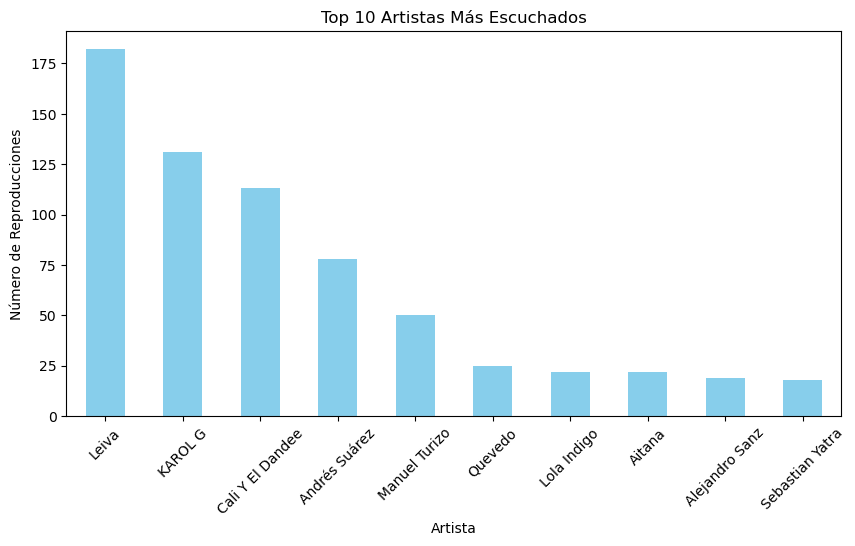

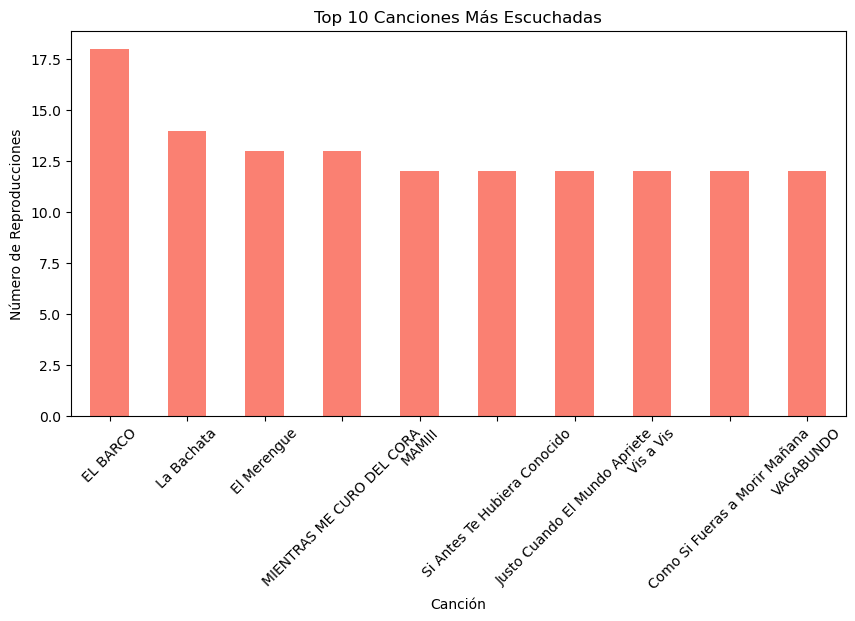

In [34]:
import matplotlib.pyplot as plt


# Cuento reproducciones por artista
artistas_top = df_filtrado['artista'].value_counts().head(10)  # Top 10 artistas

# Cuento reproducciones por canción
generos_top = df_filtrado['cancion'].value_counts().head(10)  # Top 10 canciones

# Muestro los artistas y canciones más escuchadas
print("Artistas más escuchados:")
print(artistas_top)

print("\nCanciones más escuchadas:")
print(generos_top)

# Configuro las variables en el gráfico los artistas más escuchados
plt.figure(figsize=(10, 5))
artistas_top.plot(kind='bar', color='skyblue')
plt.title('Top 10 Artistas Más Escuchados')
plt.xlabel('Artista')
plt.ylabel('Número de Reproducciones')
plt.xticks(rotation=45)
plt.show()

# Configuro las canciones más escuchadas
plt.figure(figsize=(10, 5))
generos_top.plot(kind='bar', color='salmon')
plt.title('Top 10 Canciones Más Escuchadas')
plt.xlabel('Canción')
plt.ylabel('Número de Reproducciones')
plt.xticks(rotation=45)
plt.show()

In [35]:
import requests
import pandas as pd
import json
from datetime import datetime

# 3. SETLIST

* Voy a buscar conciertos en la API de SETLIST de mis artistas más escuchado

## 3.1. Conciertos de Leiva

In [39]:
# Configuro mi API Key
API_KEY = 'SW6gsCndHIAQ5MBu6fmtPrZDNBGRWSOMv6vd'
HEADERS = {'x-api-key': API_KEY, 'Accept': 'application/json'}

# Busco setlists recientes por artista
artista = "Leiva"
url = f"https://api.setlist.fm/rest/1.0/search/setlists?artistName={artista}&p=1"

# Hago la solicitud a la API
response = requests.get(url, headers=HEADERS, verify = False)

# Verifico si la solicitud fue exitosa
if response.status_code == 200:
    data = response.json()
    
    # Extraigo información de los setlists
    setlists = []
    for evento in data.get('setlist', []):
        fecha = evento.get('eventDate', 'Desconocido')
        ciudad = evento['venue']['city']['name']
        canciones = [cancion['name'] for set_ in evento.get('sets', {}).get('set', []) for cancion in set_.get('song', [])]
        
        setlists.append({'fecha': fecha, 'ciudad': ciudad, 'canciones': canciones})

    # Convierto a DataFrame
    df_setlists = pd.DataFrame(setlists)
    
    # Muestro resultados
    print(df_setlists.head())

else:
    print(f"Error en la solicitud: {response.status_code}")

C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.setlist.fm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


        fecha        ciudad canciones
0  09-02-2025   Villa María        []
1  07-02-2025      Freirina        []
2  07-02-2025       Neuquén        []
3  31-01-2025     Coihaique        []
4  30-01-2025  Puerto Varas        []


## 3.2. Conciertos de Karol G

In [41]:

# Busco setlists recientes por artista
artista = "Karol G"
url = f"https://api.setlist.fm/rest/1.0/search/setlists?artistName={artista}&p=1"

# Hago la solicitud a la API
response = requests.get(url, headers=HEADERS, verify = False)

# Verifico si la solicitud fue exitosa
if response.status_code == 200:
    data = response.json()
    
    # Extraigo información de los setlists
    setlists = []
    for evento in data.get('setlist', []):
        fecha = evento.get('eventDate', 'Desconocido')
        ciudad = evento['venue']['city']['name']
        canciones = [cancion['name'] for set_ in evento.get('sets', {}).get('set', []) for cancion in set_.get('song', [])]
        
        setlists.append({'fecha': fecha, 'ciudad': ciudad, 'canciones': canciones})

    # Convierto a DataFrame
    df_setlists = pd.DataFrame(setlists)
    
    # Muestro resultados
    print(df_setlists.head())

else:
    print(f"Error en la solicitud: {response.status_code}")

C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.setlist.fm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


        fecha          ciudad  \
0  08-12-2024        Medellín   
1  20-09-2024  Rio de Janeiro   
2  11-09-2024          Elmont   
3  23-07-2024          Madrid   
4  22-07-2024          Madrid   

                                           canciones  
0  [AMARGURA, QLONA, EL MAKINON, MI EX TENÍA RAZÓ...  
1  [BICHOTAG, OKI DOKI, Tusa, AMARGURA, UNA NOCHE...  
2                     [Si Antes Te Hubiera Conocido]  
3  [Intro, TQG, BESTIES, Mi cama, EL BARCO, X SI ...  
4  [TQG, BESTIES, Mi Cama, EL BARCO, X SI VOLVEMO...  


## 3.3. Cali Y El Dandee

In [43]:
artista = "Cali Y El Dandee"
url = f"https://api.setlist.fm/rest/1.0/search/setlists?artistName={artista}&p=1"

# Hago la solicitud a la API
response = requests.get(url, headers=HEADERS, verify = False)

# Verifico si la solicitud fue exitosa
if response.status_code == 200:
    data = response.json()
    
    # Extraigo información de los setlists
    setlists = []
    for evento in data.get('setlist', []):
        fecha = evento.get('eventDate', 'Desconocido')
        ciudad = evento['venue']['city']['name']
        canciones = [cancion['name'] for set_ in evento.get('sets', {}).get('set', []) for cancion in set_.get('song', [])]
        
        setlists.append({'fecha': fecha, 'ciudad': ciudad, 'canciones': canciones})

    # Convierto a DataFrame
    df_setlists = pd.DataFrame(setlists)
    
    # Muestro resultados
    print(df_setlists.head())

else:
    print(f"Error en la solicitud: {response.status_code}")

C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.setlist.fm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


        fecha     ciudad canciones
0  01-08-2024   Burriana        []
1  23-07-2024  Santander        []
2  12-07-2024  Tomelloso        []
3  28-06-2024   Valencia        []
4  22-06-2024    Seville        []


## 3.4. Manuel Turizo

In [45]:
artista = "Manuel Turizo"
url = f"https://api.setlist.fm/rest/1.0/search/setlists?artistName={artista}&p=1"

# Hago la solicitud a la API
response = requests.get(url, headers=HEADERS, verify = False)

# Verifico si la solicitud fue exitosa
if response.status_code == 200:
    data = response.json()
    
    # Extraigo información de los setlists
    setlists = []
    for evento in data.get('setlist', []):
        fecha = evento.get('eventDate', 'Desconocido')
        ciudad = evento['venue']['city']['name']
        canciones = [cancion['name'] for set_ in evento.get('sets', {}).get('set', []) for cancion in set_.get('song', [])]
        
        setlists.append({'fecha': fecha, 'ciudad': ciudad, 'canciones': canciones})

    # Convierto a DataFrame
    df_setlists = pd.DataFrame(setlists)
    
    # Muestro resultados
    print(df_setlists.head())

else:
    print(f"Error en la solicitud: {response.status_code}")

C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.setlist.fm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


        fecha     ciudad                                          canciones
0  08-11-2024  Barcelona                                                 []
1  26-10-2024      Miami  [Vaina loca, La nota, Desconocidos, La bachata...
2  06-10-2024     Madrid  [Vaina loca, Desconocidos, Copa vacía, Qué pec...
3  03-10-2024     Madrid                                        [Qué pecao]
4  13-09-2024     Getafe                                                 []


## 3.5. Quevedo

In [47]:
artista = "Quevedo"
url = f"https://api.setlist.fm/rest/1.0/search/setlists?artistName={artista}&p=1"

# Hago la solicitud a la API
response = requests.get(url, headers=HEADERS, verify = False)

# Verifico si la solicitud fue exitosa
if response.status_code == 200:
    data = response.json()
    
    # Extraigo información de los setlists
    setlists = []
    for evento in data.get('setlist', []):
        fecha = evento.get('eventDate', 'Desconocido')
        ciudad = evento['venue']['city']['name']
        canciones = [cancion['name'] for set_ in evento.get('sets', {}).get('set', []) for cancion in set_.get('song', [])]
        
        setlists.append({'fecha': fecha, 'ciudad': ciudad, 'canciones': canciones})

    # Convierto a DataFrame
    df_setlists = pd.DataFrame(setlists)
    
    # Muestro resultados
    print(df_setlists.head())

else:
    print(f"Error en la solicitud: {response.status_code}")

C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.setlist.fm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


        fecha       ciudad                                          canciones
0  19-02-2025       Madrid  [KASSANDRA, DURO, CHAPIADORA.COM, 14 FEBREROS,...
1  18-02-2025       Madrid                                                 []
2  17-02-2025       Madrid  [KASSANDRA, DURO, CHAPIADORA.COM, 14 FEBREROS,...
3  10-02-2025  Villa María                                                 []
4  15-01-2025  Jesús María                                                 []


## 3.6. Lola Índigo

In [49]:
artista = "Lola Indigo"
url = f"https://api.setlist.fm/rest/1.0/search/setlists?artistName={artista}&p=1"

# Hago la solicitud a la API
response = requests.get(url, headers=HEADERS, verify = False)

# Verifico si la solicitud fue exitosa
if response.status_code == 200:
    data = response.json()
    
    # Extraigo información de los setlists
    setlists = []
    for evento in data.get('setlist', []):
        fecha = evento.get('eventDate', 'Desconocido')
        ciudad = evento['venue']['city']['name']
        canciones = [cancion['name'] for set_ in evento.get('sets', {}).get('set', []) for cancion in set_.get('song', [])]
        
        setlists.append({'fecha': fecha, 'ciudad': ciudad, 'canciones': canciones})

    # Convierto a DataFrame
    df_setlists = pd.DataFrame(setlists)
    
    # Muestro resultados
    print(df_setlists.head())

else:
    print(f"Error en la solicitud: {response.status_code}")

C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.setlist.fm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


        fecha     ciudad                                          canciones
0  08-02-2025    Granada                                                 []
1  20-12-2024     Madrid                    [PERREITO PA LLORAR / La Reina]
2  09-12-2024     Madrid  [De plastilina, El Condenao, LA PRIMAVERA, El ...
3  30-11-2024     Bogota  [AN1MAL, La niña de la escuela, PERREITO PA LL...
4  08-11-2024  Barcelona                                         [La Reina]


### ---> Coincidencias de mi historial de Spotify y Setlist

* Ahora voy a cruzar los datos con mi historial de Spotify de mis artistas más escuchados para ver qué canciones han sonado en mi cuenta de las que aparecen en estos conciertos de Setlist

In [52]:
# lista de canciones de conciertos en un solo conjunto
canciones_conciertos = set(cancion for lista in df_setlists['canciones'] for cancion in lista)

# Filtro el historial de Spotify para ver si ha escuchado esas canciones
df_filtrado['en_concierto'] = df_filtrado['cancion'].apply(lambda x: x in canciones_conciertos)

# Muestro las coincidencias
df_coincidencias = df_filtrado[df_filtrado['en_concierto']]
df_coincidencias.head()

,fecha,platform,duracion,pais,cancion,artista,album,reason_start,reason_end,shuffle,skipped,en_concierto
13074,2024-02-07,ios,232526,ES,4 besos,Lola Indigo,4 besos,trackdone,trackdone,False,False,True
13078,2024-02-07,ios,243806,ES,Casanova,Soolking,Casanova,fwdbtn,trackdone,False,False,True
13089,2024-02-10,ios,232526,ES,4 besos,Lola Indigo,4 besos,trackdone,trackdone,False,False,True
13092,2024-02-10,ios,62640,ES,Casanova,Soolking,Casanova,trackdone,unexpected-exit-while-paused,False,False,True
13095,2024-02-14,ios,181157,ES,Casanova,Soolking,Casanova,fwdbtn,trackdone,True,False,True


* La lista de coincidencias no me ha parecido demasiado relevante por lo que usaré esto

# 4. SPOTIFY

* Voy a usar la API de Spotify para extraer el género de cada uno de los artistas que he escuchado

In [56]:
import certifi
print(certifi.where())

C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\certifi\cacert.pem


In [57]:
import requests

url = "https://accounts.spotify.com/api/token"
response = requests.get(url, verify=False)

print("Código de respuesta:", response.status_code)

Código de respuesta: 405


C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'accounts.spotify.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [58]:

import requests
import base64


CLIENT_ID = "45947e75b14845e09af3755425a1784e"
CLIENT_SECRET = "f91d7b6b900a4541bb4b8f8c1995541a"

# Codifico credenciales
credentials = f"{CLIENT_ID}:{CLIENT_SECRET}"
encoded_credentials = base64.b64encode(credentials.encode()).decode()

# URL de autenticación para conseguir el token que necesito
url = "https://accounts.spotify.com/api/token"

# Headers y datos para la petición POST
headers = {
    "Authorization": f"Basic {encoded_credentials}",
    "Content-Type": "application/x-www-form-urlencoded"
}

data = {
    "grant_type": "client_credentials"
}

# Hago la petición POST
response = requests.post(url, headers=headers, data=data, verify = False)

# Muestro la respuesta
if response.status_code == 200:
    token = response.json()["access_token"]
    print("Token obtenido:", token)
else:
    print("Error:", response.status_code, response.text)

Token obtenido: BQCLYfMEFQ6ev2HPMnQGeuzMqtg2EEUic092nCAII7QccchpYlg82KYL0LsXEKJiRiUDuzrCrb_6dFShPEiz5h26S6IZLfjBesQsNheOs5M5lEMY1agNHQoEW9Ks42GQEMu2XasEDQY


C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'accounts.spotify.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


## 4.1. Género para mis artistas más escuchados

* Voy a buscar en la API de Spotify el género de mis arristas más escuchados

In [61]:
import pandas as pd
import requests
# Mi DataFrame con los nombres de los artistas
df_genero = pd.DataFrame({"artista": ['Leiva', 'KAROL G', 'Cali Y El Dandee', 'Andrés Suárez', 
                                        'Manuel Turizo', 'Quevedo', 'Lola Indigo', 'Aitana' , 'Alejandro Sanz' ,
                                        'Sebastian Yatra']})  

# Mi token de acceso
TOKEN = "BQBKxL9q34WEQfppBuIGd6r-MTKw733X045iLc4gRPtTNNrGAhVjvY4Wr9lRVmGu_JgNLG8mRK_RL4WLFfe0ZJ7WhrY5gRLnfeDB9lJScPyOIYLVjLKFr2eDzM4diuPPZhXGL9qdSrE"

# 🔹 Función para obtener el género de un artista
def obtener_genero(artista):
    url = f"https://api.spotify.com/v1/search"
    headers = {"Authorization": f"Bearer {TOKEN}"}
    params = {"q": artista, "type": "artist", "limit": 1}

    response = requests.get(url, headers=headers, params=params, verify = False)
    
    if response.status_code == 200:
        data = response.json()
        artistas = data.get("artists", {}).get("items", [])
        if artistas:
            return ", ".join(artistas[0].get("genres", ["Sin género"]))
    
    return "No encontrado"

# Aplico la función a cada artista en el DataFrame
df_genero["género"] = df_genero["artista"].apply(obtener_genero)

# Muestro el resultado
df_genero

C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.spotify.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.spotify.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.spotify.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\User

,artista,género
0,Leiva,
1,KAROL G,"reggaeton, latin, urbano latino"
2,Cali Y El Dandee,"colombian pop, reggaeton"
3,Andrés Suárez,"singer-songwriter, trova"
4,Manuel Turizo,"reggaeton, latin, colombian pop"
5,Quevedo,reggaeton
6,Lola Indigo,
7,Aitana,
8,Alejandro Sanz,latin pop
9,Sebastian Yatra,"colombian pop, reggaeton, latin"


## 4.2. Creación columna género

* He decidido hacerlo parea todos los artistas que he escuchado los dos últimos años para hacer una visualización de los géneros que más suenan en mi cuenta en esta plataforma

In [64]:
import requests
import base64


CLIENT_ID = "45947e75b14845e09af3755425a1784e"
CLIENT_SECRET = "f91d7b6b900a4541bb4b8f8c1995541a"

# Codifico credenciales
credentials = f"{CLIENT_ID}:{CLIENT_SECRET}"
encoded_credentials = base64.b64encode(credentials.encode()).decode()

# URL de autenticación para conseguir el token que necesito
url = "https://accounts.spotify.com/api/token"

# Headers y datos para la petición POST
headers = {
    "Authorization": f"Basic {encoded_credentials}",
    "Content-Type": "application/x-www-form-urlencoded"
}

data = {
    "grant_type": "client_credentials"
}

# Hago la petición POST
response = requests.post(url, headers=headers, data=data, verify = False)

# Muestro la respuesta
if response.status_code == 200:
    token = response.json()["access_token"]
    print("Token obtenido:", token)
else:
    print("Error:", response.status_code, response.text)

Token obtenido: BQBPeYLQ7tBaCRkYPkdJq-gc1xSfrnMttKL7BkmWqmMpsLVCQd3v26PAIx1z39KnalLOrWVkx-t7f8CPasQqgM7jN0TyJGD7cdQJLYhWwMWDiZ0In3qNxE9jjJ5N7P4V_FPFew6ci00


C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'accounts.spotify.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [65]:
import requests
import pandas as pd
import time
# elimino para que no me haga consultas repetidas por artista 
df_filtrado = df_filtrado.drop_duplicates(subset = ['artista'])
# Mi token de acceso de Spotify
TOKEN = "BQBKxL9q34WEQfppBuIGd6r-MTKw733X045iLc4gRPtTNNrGAhVjvY4Wr9lRVmGu_JgNLG8mRK_RL4WLFfe0ZJ7WhrY5gRLnfeDB9lJScPyOIYLVjLKFr2eDzM4diuPPZhXGL9qdSrE"

# Función para obtener el género de un artista
def obtener_genero(artista):
    url = "https://api.spotify.com/v1/search"
    headers = {"Authorization": f"Bearer {TOKEN}"}
    params = {"q": artista, "type": "artist", "limit": 1}

    response = requests.get(url, headers=headers, params=params, verify = False)

    if response.status_code == 200:
        data = response.json()
        artistas = data.get("artists", {}).get("items", [])
        if artistas:
            return ", ".join(artistas[0].get("genres", ["Sin género"]))

    return "No encontrado"

# Aplico la función a cada artista en el DataFrame con un pequeño delay para evitar bloqueos
df_filtrado["género"] = df_filtrado["artista"].apply(lambda x: obtener_genero(x) or "No encontrado")
    
    # df_filtrado["género"] = df_filtrado["artista"].map(obtener_genero)

    # Pequeña pausa entre cada solicitud para no ser bloqueado por la API
time.sleep(1)

# Muestro el resultado
df_filtrado

C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.spotify.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.spotify.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\67755488\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.spotify.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\User

,fecha,platform,duracion,pais,cancion,artista,album,reason_start,reason_end,shuffle,skipped,en_concierto,género
12489,2023-02-24,android,9591,ES,Si Tú Me Llamas - BSO Tadeo Jones 3,Omar Montes,Si Tú Me Llamas,playbtn,endplay,True,True,False,"flamenco, flamenco urbano, flamenco pop"
12490,2023-02-24,android,162637,ES,La Bachata,Manuel Turizo,La Bachata,trackdone,trackdone,True,False,False,"reggaeton, latin, colombian pop"
12491,2023-02-24,android,18799,ES,K alegría,DELLAFUENTE,K alegría,trackdone,endplay,True,True,False,"flamenco urbano, flamenco"
12492,2023-02-24,android,200454,ES,Flowers,Miley Cyrus,Flowers,playbtn,trackdone,True,False,False,No encontrado
12493,2023-02-24,android,200739,ES,Seaside,Diane Warren,"Diane Warren: The Cave Sessions, Vol. 1",trackdone,trackdone,True,False,False,No encontrado
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13867,2024-12-23,ios,164639,ES,Ser Un Cantante,Caracol Televisión,Lo Mejor de la Reina del Flow,trackdone,unexpected-exit-while-paused,True,False,False,No encontrado
13884,2025-01-07,ios,125959,ES,Impulsivo (feat. Manuel Turizo),Justin Quiles,Realidad,trackdone,logout,True,False,False,reggaeton
13902,2025-01-22,ios,242546,ES,Aurora - Remix,Jhosy,Aurora,trackdone,trackdone,True,False,False,champeta
13913,2025-01-25,ios,3181,ES,Si Preguntan Por Mi,Chris Lebron,Si Preguntan Por Mi,fwdbtn,fwdbtn,True,True,False,bachata


In [66]:
df_filtrado.género.value_counts()

género
No encontrado                                               87
reggaeton                                                   14
latin pop                                                   13
reggaeton, urbano latino                                     7
reggaeton, latin                                             7
                                                            ..
latin pop, italo dance                                       1
colombian pop, reggaeton, latin                              1
norwegian pop                                                1
salsa, salsa romantica, latin jazz, merengue, son cubano     1
champeta                                                     1
Name: count, Length: 125, dtype: int64

### ---> Top géneros más escuchados

C:\Users\67755488\AppData\Local\Temp\ipykernel_24100\3552938681.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.values, y=top_generos.index, palette="rocket")


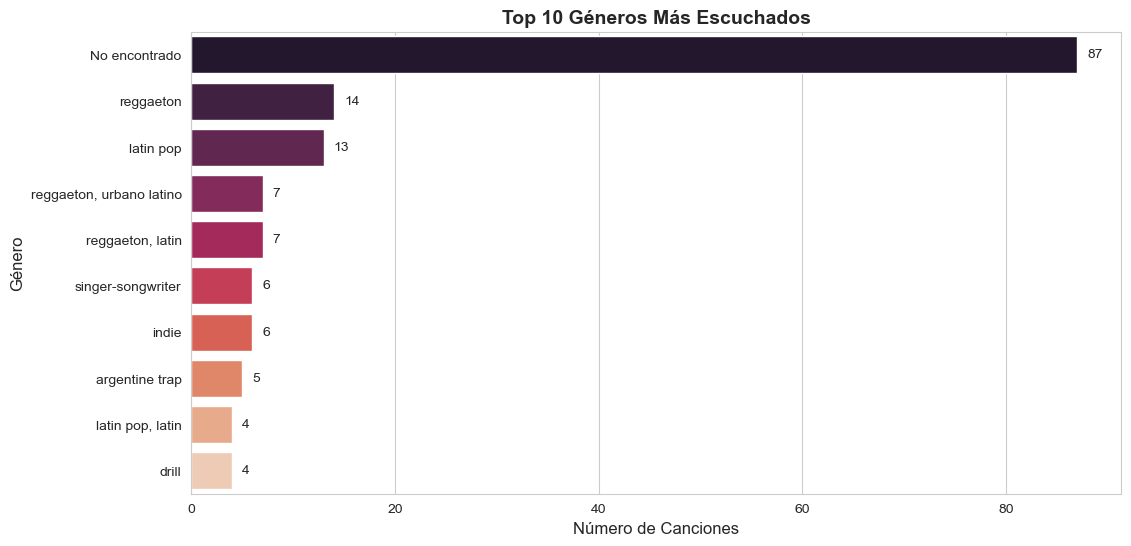

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cuento cuántas veces aparece cada género
top_generos = df_filtrado["género"].value_counts().head(10)

# Configuro el estilo del gráfico
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Voy a crear un gráfico de barras
sns.barplot(x=top_generos.values, y=top_generos.index, palette="rocket")

# Agrego etiquetas y título
plt.xlabel("Número de Canciones", fontsize=12)
plt.ylabel("Género", fontsize=12)
plt.title("Top 10 Géneros Más Escuchados", fontsize=14, fontweight="bold")

# Muestro los valores en las barras
for index, value in enumerate(top_generos.values):
    plt.text(value + 1, index, str(value), va='center', fontsize=10)

# Muestro el gráfico
plt.show()

* Voy a eliminar los artistas para los que no tengo género. Aunque esto eliminará algunos de los cantantes de mi top 10, no he conseguido tener esta información y será más fácil trabajar sin ellos.

In [70]:
df_filtrado.shape

(289, 13)

In [71]:
# Elimino los artistas que quiero
df_filtrado = df_filtrado[df_filtrado["género"] != "No encontrado"].dropna(subset=["género"])

# Verifico los géneros restantes
df_filtrado["género"].value_counts()

género
reggaeton                                                   14
latin pop                                                   13
reggaeton, urbano latino                                     7
reggaeton, latin                                             7
singer-songwriter                                            6
                                                            ..
latin pop, italo dance                                       1
colombian pop, reggaeton, latin                              1
norwegian pop                                                1
salsa, salsa romantica, latin jazz, merengue, son cubano     1
champeta                                                     1
Name: count, Length: 124, dtype: int64

In [72]:
# Verifico que se eliminaron correctamente
df_filtrado.shape

(202, 13)

## ---> Guardo CSV

In [131]:
# Guardar en CSV
ruta = "Historial_Spotify_23-24.csv"
df_filtrado.to_csv(ruta, index=False)

print(f"Archivo CSV guardado en: {ruta}")

Archivo CSV guardado en: Historial_Spotify_23-24.csv
